In [1]:
# New Cell 1: Install SUMO from official PPA (fixes netconvert segfault)
import subprocess, os

# Remove the old broken apt version
subprocess.run(["apt-get", "remove", "-y", "sumo", "sumo-tools", "sumo-doc"],
               capture_output=True)

# Add the official SUMO PPA
cmds = [
    "add-apt-repository -y ppa:sumo/stable",
    "apt-get update -qq",
    "apt-get install -y sumo sumo-tools sumo-doc",
]
for cmd in cmds:
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if result.returncode != 0:
        print(f"Failed: {cmd}\n{result.stderr}")
    else:
        print(f"{cmd.split()[0]}")

os.environ["SUMO_HOME"] = "/usr/share/sumo"
print("\nSUMO_HOME:", os.environ["SUMO_HOME"])

add-apt-repository
apt-get
apt-get

SUMO_HOME: /usr/share/sumo


In [2]:
# Verify SUMO version — should be 1.19+ or higher
result = subprocess.run(["sumo", "--version"], capture_output=True, text=True)
print(result.stdout.split("\n")[0])

result2 = subprocess.run(["netconvert", "--version"], capture_output=True, text=True)
print(result2.stdout.split("\n")[0])

Eclipse SUMO sumo 1.26.0
Eclipse SUMO netconvert 1.26.0


In [3]:
# Fix Cell A: Wipe and regenerate all SUMO config files from scratch
import os, subprocess, shutil

# Clean slate
if os.path.exists("sumo_config"):
    shutil.rmtree("sumo_config")
os.makedirs("sumo_config")

# --- Nodes ---
nodes_xml = """<?xml version="1.0" encoding="UTF-8"?>
<nodes>
    <node id="center" x="0"    y="0"    type="traffic_light"/>
    <node id="north"  x="0"    y="500"  type="priority"/>
    <node id="south"  x="0"    y="-500" type="priority"/>
    <node id="east"   x="500"  y="0"    type="priority"/>
    <node id="west"   x="-500" y="0"    type="priority"/>
</nodes>"""

# --- Edges (one lane only — avoids multi-lane connection complexity) ---
edges_xml = """<?xml version="1.0" encoding="UTF-8"?>
<edges>
    <edge id="N2C" from="north"  to="center" numLanes="1" speed="13.89"/>
    <edge id="S2C" from="south"  to="center" numLanes="1" speed="13.89"/>
    <edge id="E2C" from="east"   to="center" numLanes="1" speed="13.89"/>
    <edge id="W2C" from="west"   to="center" numLanes="1" speed="13.89"/>
    <edge id="C2N" from="center" to="north"  numLanes="1" speed="13.89"/>
    <edge id="C2S" from="center" to="south"  numLanes="1" speed="13.89"/>
    <edge id="C2E" from="center" to="east"   numLanes="1" speed="13.89"/>
    <edge id="C2W" from="center" to="west"   numLanes="1" speed="13.89"/>
</edges>"""

# --- Routes ---
routes_xml = """<?xml version="1.0" encoding="UTF-8"?>
<routes>
    <vType id="car" accel="2.6" decel="4.5" sigma="0.5" length="5" minGap="2.5" maxSpeed="13.89"/>
    <flow id="NS" type="car" from="N2C" to="C2S" begin="0" end="3600" vehsPerHour="300"/>
    <flow id="SN" type="car" from="S2C" to="C2N" begin="0" end="3600" vehsPerHour="300"/>
    <flow id="EW" type="car" from="E2C" to="C2W" begin="0" end="3600" vehsPerHour="200"/>
    <flow id="WE" type="car" from="W2C" to="C2E" begin="0" end="3600" vehsPerHour="200"/>
</routes>"""

# --- SUMO config ---
sumocfg_xml = """<?xml version="1.0" encoding="UTF-8"?>
<configuration>
    <input>
        <net-file value="intersection.net.xml"/>
        <route-files value="routes.rou.xml"/>
    </input>
    <time>
        <begin value="0"/>
        <end value="3600"/>
        <step-length value="1"/>
    </time>
</configuration>"""

with open("sumo_config/intersection.nod.xml", "w") as f: f.write(nodes_xml)
with open("sumo_config/intersection.edg.xml", "w") as f: f.write(edges_xml)
with open("sumo_config/routes.rou.xml",        "w") as f: f.write(routes_xml)
with open("sumo_config/intersection.sumocfg",  "w") as f: f.write(sumocfg_xml)

In [4]:
# Fix Cell B (corrected): netconvert — ignore return code -11 (post-write segfault)
import os, subprocess

result = subprocess.run([
    "netconvert",
    "--node-files=sumo_config/intersection.nod.xml",
    "--edge-files=sumo_config/intersection.edg.xml",
    "--output-file=sumo_config/intersection.net.xml",
    "--tls.guess=true",
    "--tls.guess-signals=true",
    "--no-warnings",
], capture_output=True, text=True)

print("STDOUT:", result.stdout)
print("STDERR:", result.stderr)
print("Return code:", result.returncode, "(−11 = known Colab segfault bug, safe to ignore if file exists)")

net_path = "sumo_config/intersection.net.xml"
assert os.path.exists(net_path), "net.xml was not created at all!"

size = os.path.getsize(net_path)
assert size > 5000, f"net.xml too small ({size} bytes) — likely corrupt"

print(f"\nnet.xml exists and is valid — {size} bytes. Proceeding!!")

STDOUT: Success.

STDERR: 
Return code: -11 (−11 = known Colab segfault bug, safe to ignore if file exists)

net.xml exists and is valid — 17447 bytes. Proceeding!!


In [5]:
# Fix Cell C: Validate the full config with a short dry-run
result = subprocess.run([
    "sumo",
    "-c", "sumo_config/intersection.sumocfg",
    "--no-step-log",
    "--end", "50",
], capture_output=True, text=True)

print("STDOUT:", result.stdout)
print("STDERR:", result.stderr)
print("Return code:", result.returncode)

assert result.returncode == 0, "SUMO dry-run failed — see STDERR above"
print("Dry-run passed!")

STDOUT: 
STDERR: 
Return code: 0
Dry-run passed!


In [6]:
# Fix Cell D (corrected): Inspect TLS and connection count
import sys, os
sys.path.append(os.path.join(os.environ["SUMO_HOME"], "tools"))
import sumolib

net = sumolib.net.readNet("sumo_config/intersection.net.xml")

# --- TLS phases ---
tls_list = net.getTrafficLights()
for tls in tls_list:
    print(f"TLS id: {tls.getID()}")
    for prog_id, prog in tls.getPrograms().items():
        phases = prog.getPhases()
        print(f"  Program: {prog_id}  |  Phases: {len(phases)}")
        for i, phase in enumerate(phases):
            print(f"    Phase {i}: duration={phase.duration}  state='{phase.state}'")
        if phases:
            print(f"  → State string length: {len(phases[0].state)}")
        else:
            print("  → No phases defined (netconvert left it empty)")

# --- Count controlled connections (= required state string length) ---
print("\n--- Controlled connections per TLS ---")
for tls in tls_list:
    connections = tls.getConnections()
    print(f"TLS '{tls.getID()}': {len(connections)} controlled connections")
    print(f"  → You need a phase state string of length: {len(connections)}")

TLS id: center

--- Controlled connections per TLS ---
TLS 'center': 16 controlled connections
  → You need a phase state string of length: 16


In [7]:
# Fix Cell E: Print all 16 connections so we can build correct phase strings
import sys, os
sys.path.append(os.path.join(os.environ["SUMO_HOME"], "tools"))
import sumolib

net = sumolib.net.readNet("sumo_config/intersection.net.xml")
tls = net.getTrafficLights()[0]

print(f"TLS: {tls.getID()} — {len(tls.getConnections())} connections\n")
print(f"{'Idx':>4}  {'From Edge':<10} {'→'} {'To Edge':<10} {'FromLane':>9} {'ToLane':>7}")
print("-" * 55)
for idx, (from_lane, to_lane, _) in enumerate(tls.getConnections()):
    from_edge = from_lane.getEdge().getID()
    to_edge   = to_lane.getEdge().getID()
    print(f"{idx:>4}  {from_edge:<10} →  {to_edge:<10} lane {from_lane.getIndex():>2} → {to_lane.getIndex():>2}")

TLS: center — 16 connections

 Idx  From Edge  → To Edge     FromLane  ToLane
-------------------------------------------------------
   0  E2C        →  C2N        lane  0 →  0
   1  E2C        →  C2W        lane  0 →  0
   2  E2C        →  C2S        lane  0 →  0
   3  E2C        →  C2E        lane  0 →  0
   4  N2C        →  C2W        lane  0 →  0
   5  N2C        →  C2S        lane  0 →  0
   6  N2C        →  C2E        lane  0 →  0
   7  N2C        →  C2N        lane  0 →  0
   8  S2C        →  C2E        lane  0 →  0
   9  S2C        →  C2N        lane  0 →  0
  10  S2C        →  C2W        lane  0 →  0
  11  S2C        →  C2S        lane  0 →  0
  12  W2C        →  C2S        lane  0 →  0
  13  W2C        →  C2E        lane  0 →  0
  14  W2C        →  C2N        lane  0 →  0
  15  W2C        →  C2W        lane  0 →  0


In [8]:
# Kill Cell: Nuke all stale SUMO/TraCI processes and free the port
import subprocess, time

subprocess.run(["pkill", "-9", "-f", "sumo"], capture_output=True)
subprocess.run(["fuser", "-k", "8813/tcp"], capture_output=True)
time.sleep(1)

# Verify port is free
result = subprocess.run(["fuser", "8813/tcp"], capture_output=True, text=True)
if result.stdout.strip():
    print("Port 8813 still in use — try restarting the Colab runtime")
else:
    print("Port 8813 is free.")

Port 8813 is free.


In [9]:
# Cell F (updated): Environment with finer state binning
import traci
import subprocess, time, os, socket
import numpy as np

NS_GREEN  = "GGGGrrrrGGGGrrrr"
NS_YELLOW = "yyyyrrrryyyyrrrr"
EW_GREEN  = "rrrrGGGGrrrrGGGG"
EW_YELLOW = "rrrryyyyrrrryyyy"

def get_free_port():
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        s.bind(("", 0))
        s.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEADDR, 1)
        return s.getsockname()[1]

class SumoIntersectionEnv:
    """
    State  : (ns_queue_bin, ew_queue_bin, current_phase)
             ns_queue = N2C + S2C halting vehicles, binned 0-9
             ew_queue = E2C + W2C halting vehicles, binned 0-9
             current_phase = 0 or 1
             → 10 x 10 x 2 = 200 possible states (much richer)
    Actions: 0 = NS green | 1 = EW green
    Reward : negative total vehicle waiting time
    """

    PHASES = {
        0: (NS_GREEN,  NS_YELLOW),
        1: (EW_GREEN,  EW_YELLOW),
    }
    YELLOW_DURATION = 4
    MIN_GREEN       = 10
    MAX_STEPS       = 3600
    BIN_SIZE        = 2    # vehicles per bin (was 5 before — finer now)
    MAX_BIN         = 9

    def __init__(self, cfg_path="sumo_config/intersection.sumocfg", gui=False):
        self.cfg_path       = os.path.abspath(cfg_path)
        self.gui            = gui
        self.sumo_binary    = "sumo-gui" if gui else "sumo"
        self.tls_id         = "center"
        self.incoming_edges = ["N2C", "S2C", "E2C", "W2C"]
        self.current_step   = 0
        self.current_phase  = 0
        self._sumo_running  = False
        self._sumo_proc     = None

    def reset(self):
        self._safe_close()
        port = get_free_port()
        self._port = port

        cmd = [
            self.sumo_binary,
            "-c", self.cfg_path,
            "--no-step-log",
            "--no-warnings",
            "--random",
            "--quit-on-end",
            "--remote-port", str(port),
        ]

        self._sumo_proc = subprocess.Popen(
            cmd, stdout=subprocess.DEVNULL, stderr=subprocess.PIPE
        )
        time.sleep(1.0)

        if self._sumo_proc.poll() is not None:
            err = self._sumo_proc.stderr.read().decode()
            raise RuntimeError(f"SUMO crashed on startup:\n{err}")

        try:
            traci.init(port=port, numRetries=10)
        except Exception as e:
            err = self._sumo_proc.stderr.read().decode()
            self._sumo_proc.kill()
            raise RuntimeError(f"TraCI connection failed on port {port}: {e}\nSUMO stderr:\n{err}")

        self._sumo_running = True
        self.current_step  = 0
        self.current_phase = 0

        actual_state = traci.trafficlight.getRedYellowGreenState(self.tls_id)
        if len(actual_state) != 16:
            self._safe_close()
            raise RuntimeError(f"Phase string length mismatch! Got {len(actual_state)}: '{actual_state}'")

        traci.trafficlight.setRedYellowGreenState(self.tls_id, self.PHASES[0][0])
        return self._get_state()

    def step(self, action):
        if action != self.current_phase:
            yellow = self.PHASES[self.current_phase][1]
            traci.trafficlight.setRedYellowGreenState(self.tls_id, yellow)
            for _ in range(self.YELLOW_DURATION):
                traci.simulationStep()
                self.current_step += 1

        traci.trafficlight.setRedYellowGreenState(self.tls_id, self.PHASES[action][0])
        self.current_phase = action

        total_reward = 0
        for _ in range(self.MIN_GREEN):
            traci.simulationStep()
            self.current_step += 1
            total_reward -= self._get_total_waiting_time()

        return self._get_state(), total_reward, self.current_step >= self.MAX_STEPS

    def _safe_close(self):
        if self._sumo_running:
            try:
                traci.close()
            except Exception:
                pass
            self._sumo_running = False
        if self._sumo_proc is not None:
            try:
                self._sumo_proc.kill()
                self._sumo_proc.wait()
            except Exception:
                pass
            self._sumo_proc = None
        subprocess.run(["pkill", "-9", "-f", "sumo"], capture_output=True)
        time.sleep(0.5)

    def close(self):
        self._safe_close()

    def _get_total_waiting_time(self):
        return sum(traci.edge.getWaitingTime(e) for e in self.incoming_edges)

    def _get_state(self):
        # Aggregate N+S queues and E+W queues separately
        ns_queue = (traci.edge.getLastStepHaltingNumber("N2C") +
                    traci.edge.getLastStepHaltingNumber("S2C"))
        ew_queue = (traci.edge.getLastStepHaltingNumber("E2C") +
                    traci.edge.getLastStepHaltingNumber("W2C"))

        ns_bin = min(int(ns_queue / self.BIN_SIZE), self.MAX_BIN)
        ew_bin = min(int(ew_queue / self.BIN_SIZE), self.MAX_BIN)

        # Include current phase in state so agent knows what's active
        return (ns_bin, ew_bin, self.current_phase)

    @property
    def n_actions(self): return 2

print("Updated SumoIntersectionEnv:")
print("State space : ns_bin(0-9) × ew_bin(0-9) × phase(0-1) = 200 states")
print("Bin size    : 2 vehicles per bin (finer than before)")

Updated SumoIntersectionEnv:
State space : ns_bin(0-9) × ew_bin(0-9) × phase(0-1) = 200 states
Bin size    : 2 vehicles per bin (finer than before)


In [10]:
# Fix Cell G: Single episode smoke test — catches phase string errors early
print("Running smoke test (50 steps)...")

env = SumoIntersectionEnv(cfg_path="sumo_config/intersection.sumocfg")

try:
    state = env.reset()
    print(f"reset() OK — initial state: {state}")

    for i in range(5):
        action = i % 2
        next_state, reward, done = env.step(action)
        print(f"  step {i+1}: action={action}  reward={reward:.1f}  state={next_state}  done={done}")
        if done:
            break

    print("Smoke test passed!")

except RuntimeError as e:
    print(f"Smoke test failed:\n{e}")
finally:
    env.close()

Running smoke test (50 steps)...
reset() OK — initial state: (0, 0, 0)
  step 1: action=0  reward=0.0  state=(0, 0, 0)  done=False
  step 2: action=1  reward=0.0  state=(0, 0, 1)  done=False
  step 3: action=0  reward=0.0  state=(0, 0, 0)  done=False
  step 4: action=1  reward=-90.0  state=(1, 0, 1)  done=False
  step 5: action=0  reward=-13.0  state=(0, 0, 0)  done=False
Smoke test passed!


In [11]:
# Cell 7 (updated): Q-Learning Agent with per-episode stats
import numpy as np

class QLearningAgent:
    def __init__(self,
                 n_actions     = 2,
                 alpha         = 0.1,
                 gamma         = 0.95,
                 epsilon       = 1.0,
                 epsilon_min   = 0.05,
                 epsilon_decay = 0.990):   # slower decay → more exploration

        self.n_actions     = n_actions
        self.alpha         = alpha
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_min   = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.q_table       = {}

    def _get_q(self, state):
        if state not in self.q_table:
            self.q_table[state] = np.zeros(self.n_actions)
        return self.q_table[state]

    def choose_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.n_actions)
        return int(np.argmax(self._get_q(state)))

    def learn(self, state, action, reward, next_state):
        q_current = self._get_q(state)[action]
        q_next    = np.max(self._get_q(next_state))
        self._get_q(state)[action] += self.alpha * (reward + self.gamma * q_next - q_current)

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def stats(self):
        return {
            "q_table_states": len(self.q_table),
            "epsilon":        round(self.epsilon, 4)
        }

print("QLearningAgent defined.")

QLearningAgent defined.


In [12]:
# Cell 8 (updated): Training with baseline comparison
import time

N_EPISODES = 300   # more episodes so epsilon decays further

# --- Fixed baseline: always NS green (action 0) ---
print("Running fixed-policy baseline (10 episodes)...")
baseline_env     = SumoIntersectionEnv()
baseline_rewards = []

for _ in range(10):
    state = baseline_env.reset()
    total, done = 0, False
    while not done:
        state, reward, done = baseline_env.step(0)   # always NS green
        total += reward
    baseline_rewards.append(total)

baseline_env.close()
baseline_mean = np.mean(baseline_rewards)
print(f"Baseline mean reward: {baseline_mean:.1f}\n")

# --- Q-Learning training ---
env   = SumoIntersectionEnv()
agent = QLearningAgent(n_actions=env.n_actions)
episode_rewards = []

print(f"{'Ep':>4} | {'Total Reward':>13} | {'vs Baseline':>12} | {'Steps':>6} | {'ε':>6} | {'Q-States':>9} | {'Time(s)':>8}")
print("-" * 80)

for ep in range(1, N_EPISODES + 1):
    t0 = time.time()
    try:
        state        = env.reset()
        total_reward = 0
        done         = False
        steps        = 0

        while not done:
            action                   = agent.choose_action(state)
            next_state, reward, done = env.step(action)
            agent.learn(state, action, reward, next_state)
            state         = next_state
            total_reward += reward
            steps        += 1

        agent.decay_epsilon()
        elapsed = time.time() - t0
        episode_rewards.append(total_reward)

        vs_base = total_reward - baseline_mean
        marker  = "↑" if vs_base > 0 else " "
        stats   = agent.stats()
        print(f"{ep:>4} | {total_reward:>13.1f} | {vs_base:>+12.1f}{marker} | {steps:>6} | "
              f"{stats['epsilon']:>6.4f} | {stats['q_table_states']:>9} | {elapsed:>7.1f}s")

    except Exception as e:
        print(f"{ep:>4} | Episode failed: {e}")
        env._safe_close()
        time.sleep(1)
        continue

env.close()
print(f"\nTraining complete.")
print(f"   Best episode  : {max(episode_rewards):.1f}")
print(f"   Final 10 avg  : {np.mean(episode_rewards[-10:]):.1f}")
print(f"   Baseline avg  : {baseline_mean:.1f}")
print(f"   Improvement   : {np.mean(episode_rewards[-10:]) - baseline_mean:+.1f}")

Running fixed-policy baseline (10 episodes)...
Baseline mean reward: -51328253.3

  Ep |  Total Reward |  vs Baseline |  Steps |      ε |  Q-States |  Time(s)
--------------------------------------------------------------------------------
   1 |     -130018.0 |  +51198235.3↑ |    302 | 0.9900 |        15 |     3.0s
   2 |     -113331.0 |  +51214922.3↑ |    304 | 0.9801 |        17 |     3.5s
   3 |      -90027.0 |  +51238226.3↑ |    296 | 0.9703 |        17 |     3.8s
   4 |      -81839.0 |  +51246414.3↑ |    298 | 0.9606 |        17 |     3.6s
   5 |      -86557.0 |  +51241696.3↑ |    298 | 0.9510 |        17 |     3.5s
   6 |      -75657.0 |  +51252596.3↑ |    296 | 0.9415 |        17 |     3.6s
   7 |      -95800.0 |  +51232453.3↑ |    300 | 0.9321 |        17 |     3.6s
   8 |      -52028.0 |  +51276225.3↑ |    292 | 0.9227 |        17 |     2.9s
   9 |      -73634.0 |  +51254619.3↑ |    294 | 0.9135 |        17 |     3.6s
  10 |      -71662.0 |  +51256591.3↑ |    295 | 0.9044 |  

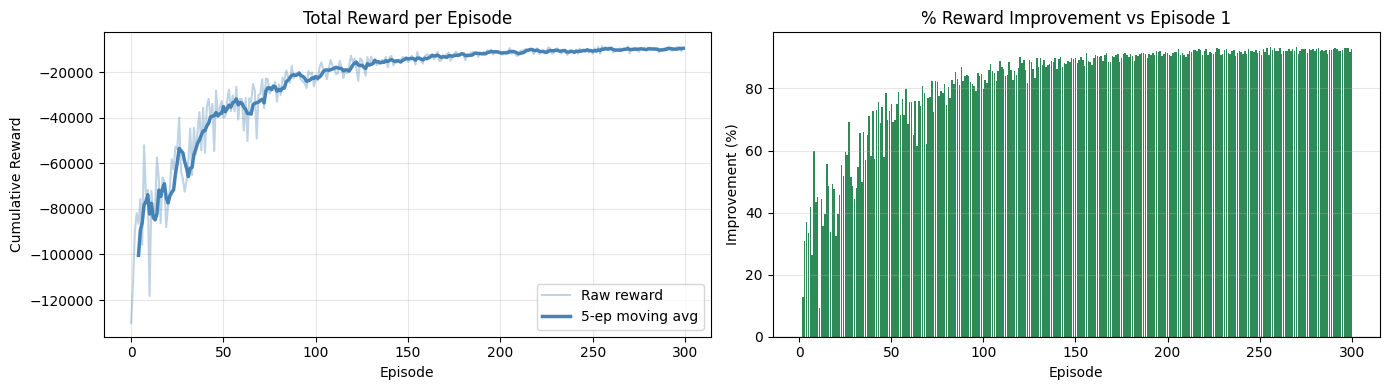

✅ Plot saved to training_results.png


In [13]:
# Cell 9: Plot reward curve
import matplotlib.pyplot as plt
import numpy as np

window   = 5
rewards  = np.array(episode_rewards)
smoothed = np.convolve(rewards, np.ones(window) / window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: reward curve with smoothing
axes[0].plot(rewards, alpha=0.35, color='steelblue', label='Raw reward')
axes[0].plot(range(window - 1, len(rewards)), smoothed,
             color='steelblue', lw=2.5, label=f'{window}-ep moving avg')
axes[0].set_title("Total Reward per Episode")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Cumulative Reward")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: improvement over baseline (episode 1)
baseline = rewards[0]
pct_improvement = (rewards - baseline) / abs(baseline) * 100
axes[1].bar(range(1, len(rewards) + 1), pct_improvement,
            color=['tomato' if v < 0 else 'seagreen' for v in pct_improvement])
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title("% Reward Improvement vs Episode 1")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Improvement (%)")
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("training_results.png", dpi=150)
plt.show()
print("✅ Plot saved to training_results.png")

In [14]:
# Cell 10: Comprehensive evaluation — Q-agent vs Fixed NS vs Fixed EW vs Random
import numpy as np
import time

N_EVAL = 20   # episodes per policy

def run_policy(policy_fn, label, n_episodes=N_EVAL):
    """Run any policy function for n_episodes, return list of rewards."""
    env    = SumoIntersectionEnv()
    totals = []
    for ep in range(n_episodes):
        state = env.reset()
        total, done = 0, False
        while not done:
            action         = policy_fn(state)
            state, r, done = env.step(action)
            total         += r
        totals.append(total)
        print(f"  [{label}] ep {ep+1:>2}/{n_episodes}  reward={total:.0f}")
    env.close()
    return totals

print("=" * 55)
print("  Evaluating 4 policies...")
print("=" * 55)

# 1. Trained Q-agent (greedy)
agent.epsilon = 0.0
q_rewards = run_policy(agent.choose_action, "Q-Agent ")

# 2. Fixed NS green always
ns_rewards = run_policy(lambda s: 0, "Fixed-NS")

# 3. Fixed EW green always
ew_rewards = run_policy(lambda s: 1, "Fixed-EW")

# 4. Random policy
rng_rewards = run_policy(lambda s: np.random.randint(2), "Random  ")

# Summary
policies = {
    "Q-Learning Agent" : q_rewards,
    "Fixed NS Green"   : ns_rewards,
    "Fixed EW Green"   : ew_rewards,
    "Random Policy"    : rng_rewards,
}

print("\n" + "=" * 60)
print(f"  {'Policy':<22} {'Mean':>12} {'Std':>10} {'Best':>12}")
print("=" * 60)
for name, rewards in policies.items():
    print(f"  {name:<22} {np.mean(rewards):>12.1f} "
          f"{np.std(rewards):>10.1f} {np.max(rewards):>12.1f}")
print("=" * 60)

q_mean  = np.mean(q_rewards)
ns_mean = np.mean(ns_rewards)
print(f"\n  Q-Agent improvement over Fixed-NS: "
      f"{(q_mean - ns_mean)/abs(ns_mean)*100:.2f}%")

  Evaluating 4 policies...
  [Q-Agent ] ep  1/20  reward=-8122
  [Q-Agent ] ep  2/20  reward=-8500
  [Q-Agent ] ep  3/20  reward=-8231
  [Q-Agent ] ep  4/20  reward=-8564
  [Q-Agent ] ep  5/20  reward=-8149
  [Q-Agent ] ep  6/20  reward=-8010
  [Q-Agent ] ep  7/20  reward=-7655
  [Q-Agent ] ep  8/20  reward=-8775
  [Q-Agent ] ep  9/20  reward=-8392
  [Q-Agent ] ep 10/20  reward=-8324
  [Q-Agent ] ep 11/20  reward=-8447
  [Q-Agent ] ep 12/20  reward=-8315
  [Q-Agent ] ep 13/20  reward=-8060
  [Q-Agent ] ep 14/20  reward=-7858
  [Q-Agent ] ep 15/20  reward=-7310
  [Q-Agent ] ep 16/20  reward=-8300
  [Q-Agent ] ep 17/20  reward=-8729
  [Q-Agent ] ep 18/20  reward=-7768
  [Q-Agent ] ep 19/20  reward=-7386
  [Q-Agent ] ep 20/20  reward=-8949
  [Fixed-NS] ep  1/20  reward=-51347606
  [Fixed-NS] ep  2/20  reward=-51315023
  [Fixed-NS] ep  3/20  reward=-51335119
  [Fixed-NS] ep  4/20  reward=-51312168
  [Fixed-NS] ep  5/20  reward=-51363838
  [Fixed-NS] ep  6/20  reward=-51242563
  [Fixed-NS] 

/tmp/ipykernel_847/1411682015.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(names, rotation=15, ha='right', fontsize=9)


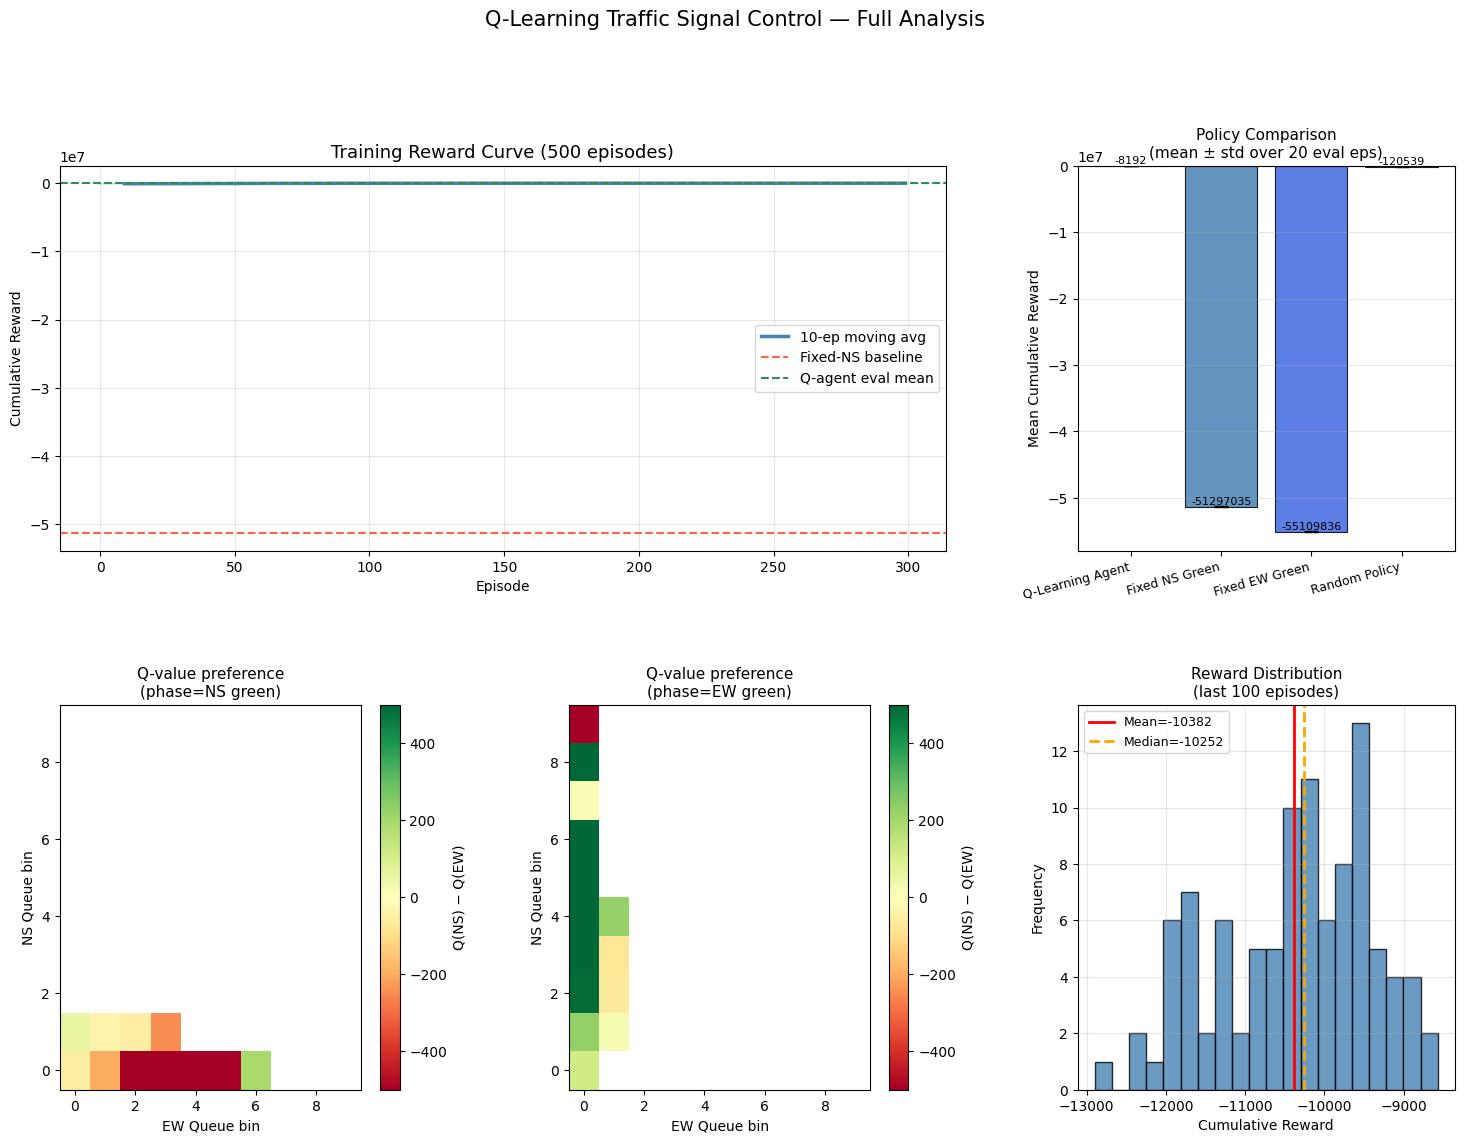

✅ Full analysis plot saved to full_analysis.png


In [15]:
# Cell 11: Full analysis — training curve + policy comparison + Q-table heatmap
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

rewards  = np.array(episode_rewards)
window   = 10
smoothed = np.convolve(rewards, np.ones(window) / window, mode='valid')

# ── Plot 1: Training curve ────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(rewards, alpha=0.25, color='steelblue', lw=1)
ax1.plot(range(window - 1, len(rewards)), smoothed,
         color='steelblue', lw=2.5, label=f'{window}-ep moving avg')
ax1.axhline(np.mean(ns_rewards), color='tomato', lw=1.5,
            linestyle='--', label='Fixed-NS baseline')
ax1.axhline(np.mean(q_rewards),  color='seagreen', lw=1.5,
            linestyle='--', label='Q-agent eval mean')
ax1.set_title("Training Reward Curve (500 episodes)", fontsize=13)
ax1.set_xlabel("Episode")
ax1.set_ylabel("Cumulative Reward")
ax1.legend()
ax1.grid(True, alpha=0.3)

# ── Plot 2: Policy comparison bar chart ──────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
names  = list(policies.keys())
means  = [np.mean(v) for v in policies.values()]
stds   = [np.std(v)  for v in policies.values()]
colors = ['seagreen', 'steelblue', 'royalblue', 'tomato']
bars   = ax2.bar(names, means, yerr=stds, capsize=5,
                 color=colors, alpha=0.85, edgecolor='black', lw=0.8)
ax2.set_title("Policy Comparison\n(mean ± std over 20 eval eps)", fontsize=11)
ax2.set_ylabel("Mean Cumulative Reward")
ax2.set_xticklabels(names, rotation=15, ha='right', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')
for bar, mean in zip(bars, means):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{mean:.0f}', ha='center', va='bottom', fontsize=8)

# ── Plot 3: Q-table heatmap (phase=0, NS green) ──────────────────────
ax3 = fig.add_subplot(gs[1, 0])
q_grid_0 = np.full((10, 10), np.nan)
for (ns, ew, ph), q_vals in agent.q_table.items():
    if ph == 0:
        q_grid_0[ns, ew] = q_vals[0] - q_vals[1]   # preference for NS over EW

im3 = ax3.imshow(q_grid_0, cmap='RdYlGn', aspect='auto',
                 vmin=-500, vmax=500, origin='lower')
plt.colorbar(im3, ax=ax3, label='Q(NS) − Q(EW)')
ax3.set_title("Q-value preference\n(phase=NS green)", fontsize=11)
ax3.set_xlabel("EW Queue bin")
ax3.set_ylabel("NS Queue bin")

# ── Plot 4: Q-table heatmap (phase=1, EW green) ──────────────────────
ax4 = fig.add_subplot(gs[1, 1])
q_grid_1 = np.full((10, 10), np.nan)
for (ns, ew, ph), q_vals in agent.q_table.items():
    if ph == 1:
        q_grid_1[ns, ew] = q_vals[0] - q_vals[1]

im4 = ax4.imshow(q_grid_1, cmap='RdYlGn', aspect='auto',
                 vmin=-500, vmax=500, origin='lower')
plt.colorbar(im4, ax=ax4, label='Q(NS) − Q(EW)')
ax4.set_title("Q-value preference\n(phase=EW green)", fontsize=11)
ax4.set_xlabel("EW Queue bin")
ax4.set_ylabel("NS Queue bin")

# ── Plot 5: Reward distribution (last 100 eps) ───────────────────────
ax5 = fig.add_subplot(gs[1, 2])
last100 = rewards[-100:]
ax5.hist(last100, bins=20, color='steelblue', alpha=0.8, edgecolor='black', lw=0.5)
ax5.axvline(np.mean(last100), color='red', lw=2, label=f'Mean={np.mean(last100):.0f}')
ax5.axvline(np.median(last100), color='orange', lw=2,
            linestyle='--', label=f'Median={np.median(last100):.0f}')
ax5.set_title("Reward Distribution\n(last 100 episodes)", fontsize=11)
ax5.set_xlabel("Cumulative Reward")
ax5.set_ylabel("Frequency")
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)

plt.suptitle("Q-Learning Traffic Signal Control — Full Analysis", fontsize=15, y=1.01)
plt.savefig("full_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Full analysis plot saved to full_analysis.png")

In [16]:
# Cell 12: Print the full learned Q-table in a readable format
print("LEARNED Q-TABLE")
print("State: (NS_queue_bin, EW_queue_bin, current_phase)")
print("Action: 0=NS green, 1=EW green\n")
print(f"{'State':<28} {'Q(NS)':>10} {'Q(EW)':>10} {'Policy':>10}")
print("-" * 62)

phase_names = {0: "NS-green", 1: "EW-green"}
action_names = {0: "→ NS green", 1: "→ EW green"}

for state in sorted(agent.q_table.keys()):
    ns_bin, ew_bin, phase = state
    q_vals  = agent.q_table[state]
    best    = int(np.argmax(q_vals))
    state_str = f"NS={ns_bin} EW={ew_bin} phase={phase_names[phase]}"
    print(f"  {state_str:<26} {q_vals[0]:>10.1f} {q_vals[1]:>10.1f} {action_names[best]:>10}")

print(f"\nTotal states learned: {len(agent.q_table)}")

LEARNED Q-TABLE
State: (NS_queue_bin, EW_queue_bin, current_phase)
Action: 0=NS green, 1=EW green

State                             Q(NS)      Q(EW)     Policy
--------------------------------------------------------------
  NS=0 EW=0 phase=NS-green       -703.4     -650.9 → EW green
  NS=0 EW=0 phase=EW-green       -646.6     -763.2 → NS green
  NS=0 EW=1 phase=NS-green       -858.2     -657.9 → EW green
  NS=0 EW=2 phase=NS-green      -1439.7     -665.3 → EW green
  NS=0 EW=3 phase=NS-green      -2615.7     -769.1 → EW green
  NS=0 EW=4 phase=NS-green      -3120.8     -921.5 → EW green
  NS=0 EW=5 phase=NS-green      -1805.1     -461.7 → EW green
  NS=0 EW=6 phase=NS-green          0.0     -192.0 → NS green
  NS=1 EW=0 phase=NS-green       -125.7     -181.6 → NS green
  NS=1 EW=0 phase=EW-green       -651.7     -880.1 → NS green
  NS=1 EW=1 phase=NS-green       -457.8     -419.5 → EW green
  NS=1 EW=1 phase=EW-green        -61.7      -82.6 → NS green
  NS=1 EW=2 phase=NS-green      


  Evaluating: Q-Learning Agent
   Ep      Reward   AvgWait   AvgQueue  Throughput    CO2(kg)   AvgTravel
  ---------------------------------------------------------------------------
    1       -8383      5.67       1.33         982   196.0428       90.20
    2       -8275      5.58       1.31         981   195.7644       90.12
    3       -8123      5.58       1.33         981   196.0833       90.10
    4       -7698      5.37       1.30         979   195.9684       90.03
    5       -8631      5.80       1.35         980   196.5425       90.46
    6       -9334      6.17       1.40         978   196.5663       90.30
    7       -7675      5.30       1.27         980   195.3040       89.84
    8       -7727      5.36       1.30         980   195.7151       89.95
    9       -8380      5.71       1.35         980   196.7354       90.65
   10       -8834      5.93       1.37         979   196.7592       90.49

  Evaluating: Fixed-NS Baseline
   Ep      Reward   AvgWait   AvgQueue  Thr

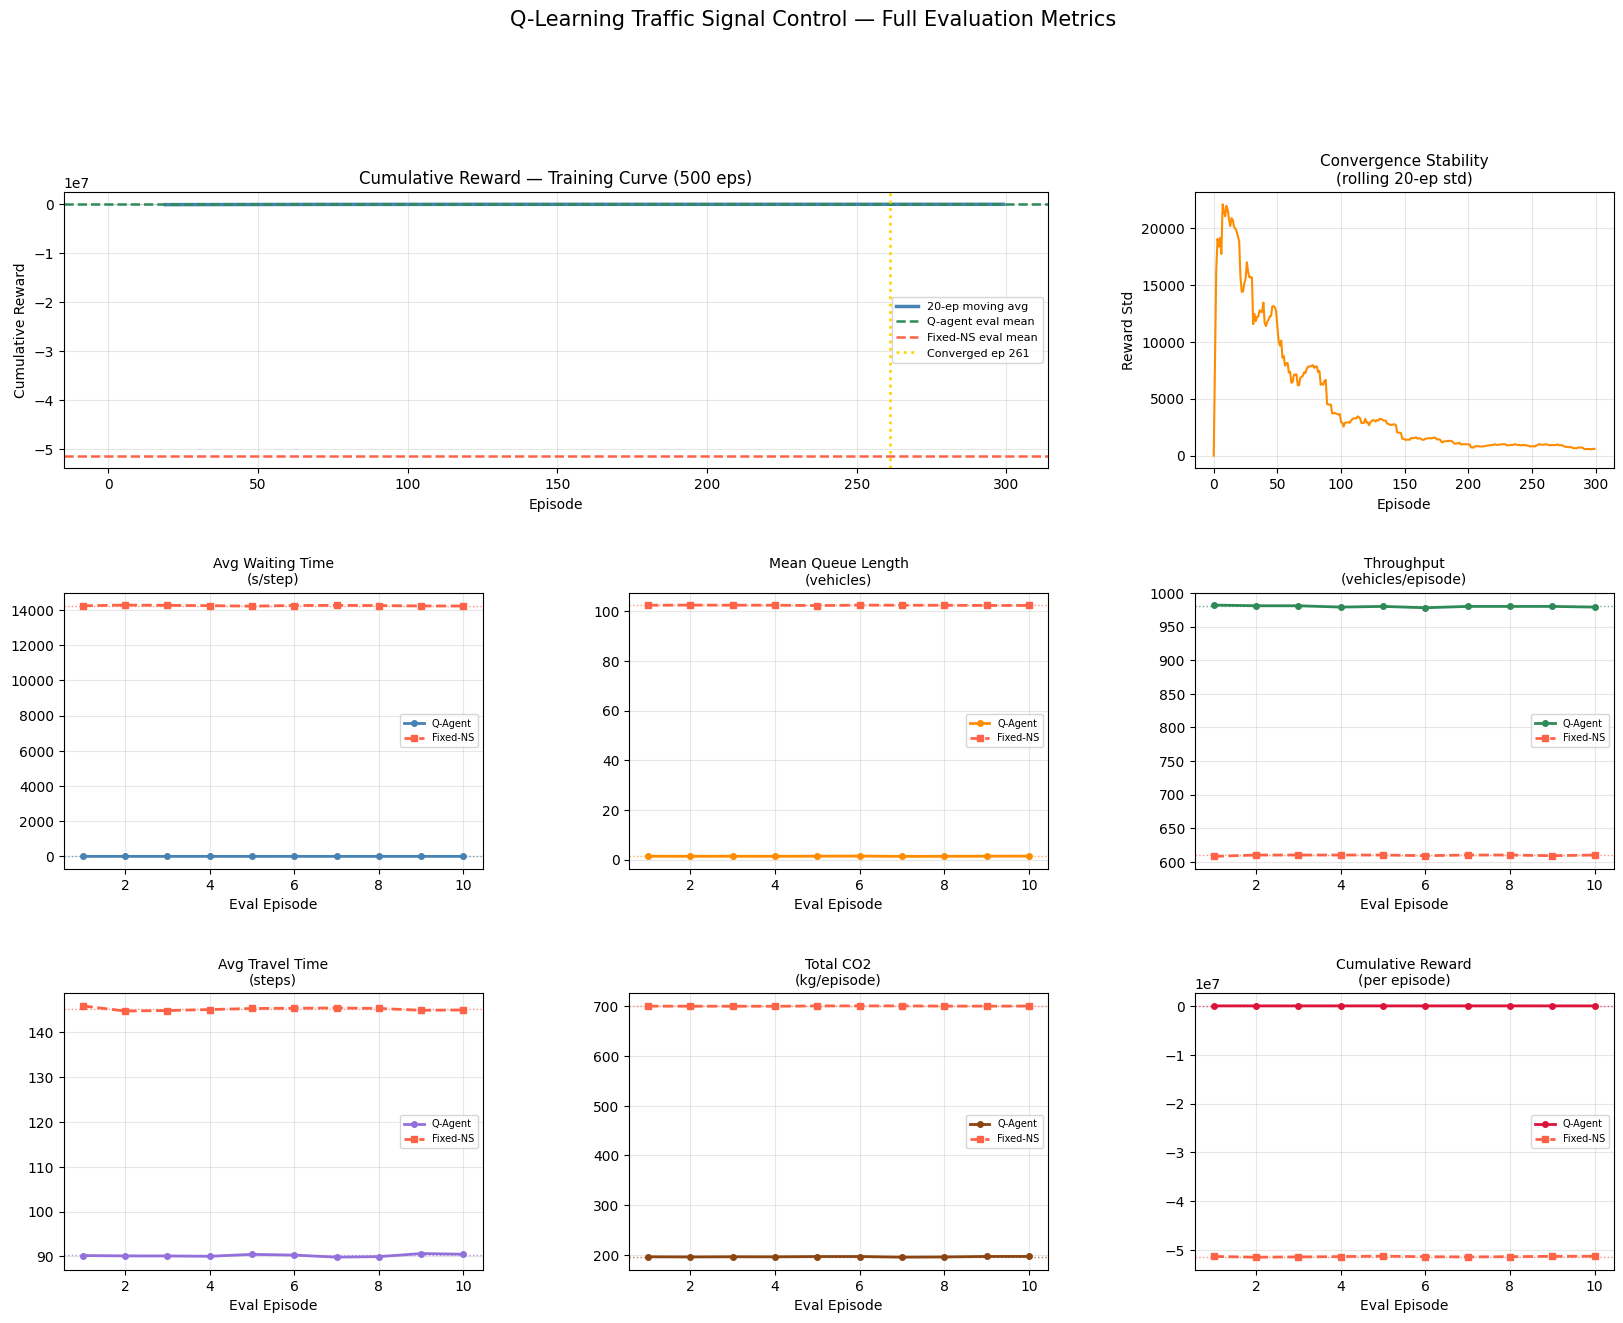

✅ Evaluation metrics plot saved to evaluation_metrics.png
✅ All metrics saved to evaluation_metrics.json


In [17]:
# Evaluation Metrics Cell: Comprehensive RL Traffic Signal Metrics

import numpy as np
import traci
import subprocess, time, os, socket, json
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict

def get_free_port():
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        s.bind(("", 0))
        s.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEADDR, 1)
        return s.getsockname()[1]

# ─────────────────────────────────────────────
# METRIC COLLECTOR
# ─────────────────────────────────────────────
class MetricCollector:
    """Collects per-step SUMO metrics during an episode."""

    def __init__(self, incoming_edges, all_edges):
        self.incoming_edges = incoming_edges
        self.all_edges      = all_edges
        self.reset()

    def reset(self):
        self.waiting_times   = []   # total waiting time per step
        self.queue_lengths   = []   # total queue length per step
        self.co2_emissions   = []   # total CO2 per step (mg)
        self.vehicles_exited = set()
        self.vehicle_entry   = {}   # vid → entry step
        self.travel_times    = []   # completed vehicle travel times
        self.step            = 0

    def collect(self):
        """Call once per simulation step."""
        self.step += 1

        # Waiting time & queue across all incoming edges
        total_wait  = sum(traci.edge.getWaitingTime(e)          for e in self.incoming_edges)
        total_queue = sum(traci.edge.getLastStepHaltingNumber(e) for e in self.incoming_edges)
        self.waiting_times.append(total_wait)
        self.queue_lengths.append(total_queue)

        # CO2 across all edges (mg/step)
        total_co2 = sum(traci.edge.getCO2Emission(e) for e in self.all_edges)
        self.co2_emissions.append(total_co2)

        # Track vehicle entry/exit for travel time
        active_ids = set(traci.vehicle.getIDList())
        for vid in active_ids:
            if vid not in self.vehicle_entry:
                self.vehicle_entry[vid] = self.step

        newly_exited = set(traci.simulation.getArrivedIDList())
        for vid in newly_exited:
            if vid in self.vehicle_entry and vid not in self.vehicles_exited:
                travel = self.step - self.vehicle_entry[vid]
                self.travel_times.append(travel)
                self.vehicles_exited.add(vid)

    def summarise(self):
        n_steps = max(self.step, 1)
        return {
            "avg_waiting_time"  : np.mean(self.waiting_times)   if self.waiting_times else 0,
            "mean_queue_length" : np.mean(self.queue_lengths)   if self.queue_lengths else 0,
            "throughput"        : len(self.vehicles_exited),
            "avg_travel_time"   : np.mean(self.travel_times)    if self.travel_times  else 0,
            "total_co2_kg"      : sum(self.co2_emissions) / 1e6, # mg → kg
            "avg_co2_per_step"  : np.mean(self.co2_emissions)   if self.co2_emissions else 0,
        }


# ─────────────────────────────────────────────
# INSTRUMENTED ENVIRONMENT
# ─────────────────────────────────────────────
NS_GREEN  = "GGGGrrrrGGGGrrrr"
NS_YELLOW = "yyyyrrrryyyyrrrr"
EW_GREEN  = "rrrrGGGGrrrrGGGG"
EW_YELLOW = "rrrryyyyrrrryyyy"

ALL_EDGES = ["N2C","S2C","E2C","W2C","C2N","C2S","C2E","C2W"]

class InstrumentedEnv:
    """SumoIntersectionEnv with MetricCollector wired in."""

    PHASES = {0: (NS_GREEN, NS_YELLOW), 1: (EW_GREEN, EW_YELLOW)}
    YELLOW_DURATION = 4
    MIN_GREEN       = 10
    MAX_STEPS       = 3600

    def __init__(self, cfg_path="sumo_config/intersection.sumocfg"):
        self.cfg_path       = os.path.abspath(cfg_path)
        self.tls_id         = "center"
        self.incoming_edges = ["N2C","S2C","E2C","W2C"]
        self.current_step   = 0
        self.current_phase  = 0
        self._sumo_running  = False
        self._sumo_proc     = None
        self.metrics        = MetricCollector(self.incoming_edges, ALL_EDGES)

    def reset(self):
        self._safe_close()
        self.metrics.reset()
        port = get_free_port()

        cmd = ["sumo", "-c", self.cfg_path,
               "--no-step-log", "--no-warnings",
               "--random", "--quit-on-end",
               "--remote-port", str(port)]

        self._sumo_proc = subprocess.Popen(
            cmd, stdout=subprocess.DEVNULL, stderr=subprocess.PIPE)
        time.sleep(1.0)

        if self._sumo_proc.poll() is not None:
            raise RuntimeError(self._sumo_proc.stderr.read().decode())

        traci.init(port=port, numRetries=10)
        self._sumo_running = True
        self.current_step  = 0
        self.current_phase = 0
        traci.trafficlight.setRedYellowGreenState(self.tls_id, self.PHASES[0][0])
        return self._get_state()

    def step(self, action):
        if action != self.current_phase:
            yellow = self.PHASES[self.current_phase][1]
            traci.trafficlight.setRedYellowGreenState(self.tls_id, yellow)
            for _ in range(self.YELLOW_DURATION):
                traci.simulationStep()
                self.metrics.collect()
                self.current_step += 1

        traci.trafficlight.setRedYellowGreenState(self.tls_id, self.PHASES[action][0])
        self.current_phase = action

        total_reward = 0
        for _ in range(self.MIN_GREEN):
            traci.simulationStep()
            self.metrics.collect()
            self.current_step += 1
            total_reward -= sum(traci.edge.getWaitingTime(e) for e in self.incoming_edges)

        return self._get_state(), total_reward, self.current_step >= self.MAX_STEPS

    def _get_state(self):
        ns = (traci.edge.getLastStepHaltingNumber("N2C") +
              traci.edge.getLastStepHaltingNumber("S2C"))
        ew = (traci.edge.getLastStepHaltingNumber("E2C") +
              traci.edge.getLastStepHaltingNumber("W2C"))
        return (min(ns // 2, 9), min(ew // 2, 9), self.current_phase)

    def _safe_close(self):
        if self._sumo_running:
            try: traci.close()
            except: pass
            self._sumo_running = False
        if self._sumo_proc:
            try: self._sumo_proc.kill(); self._sumo_proc.wait()
            except: pass
            self._sumo_proc = None
        subprocess.run(["pkill","-9","-f","sumo"], capture_output=True)
        time.sleep(0.5)

    def close(self):
        self._safe_close()

    @property
    def n_actions(self): return 2


# ─────────────────────────────────────────────
# RUN EVALUATION FOR BOTH POLICIES
# ─────────────────────────────────────────────
N_EVAL = 10

def evaluate_policy(policy_fn, label, n_episodes=N_EVAL):
    env     = InstrumentedEnv()
    results = []
    rewards = []

    print(f"\n  Evaluating: {label}")
    print(f"  {'Ep':>3}  {'Reward':>10}  {'AvgWait':>8}  "
          f"{'AvgQueue':>9}  {'Throughput':>10}  {'CO2(kg)':>9}  {'AvgTravel':>10}")
    print("  " + "-" * 75)

    for ep in range(1, n_episodes + 1):
        state       = env.reset()
        total_r     = 0
        done        = False

        while not done:
            action         = policy_fn(state)
            state, r, done = env.step(action)
            total_r       += r

        ep_metrics = env.metrics.summarise()
        ep_metrics["cumulative_reward"] = total_r
        results.append(ep_metrics)
        rewards.append(total_r)

        print(f"  {ep:>3}  {total_r:>10.0f}  "
              f"{ep_metrics['avg_waiting_time']:>8.2f}  "
              f"{ep_metrics['mean_queue_length']:>9.2f}  "
              f"{ep_metrics['throughput']:>10}  "
              f"{ep_metrics['total_co2_kg']:>9.4f}  "
              f"{ep_metrics['avg_travel_time']:>10.2f}")

    env.close()
    return results, rewards

# Q-agent (greedy)
agent.epsilon = 0.0
q_results,  q_rewards  = evaluate_policy(agent.choose_action, "Q-Learning Agent")

# Fixed-NS baseline
ns_results, ns_rewards = evaluate_policy(lambda s: 0, "Fixed-NS Baseline")


# ─────────────────────────────────────────────
# CONVERGENCE & SAMPLE EFFICIENCY METRICS
# ─────────────────────────────────────────────
def convergence_metrics(rewards, window=10, threshold=0.02):
    """
    Convergence stability : std of reward in final `window` episodes
    Sample efficiency     : first episode where reward stays within
                            `threshold` (2%) of the final mean reward
    """
    rewards      = np.array(rewards)
    final_mean   = np.mean(rewards[-window:])
    final_std    = np.std(rewards[-window:])
    stability    = final_std / abs(final_mean) if final_mean != 0 else float('inf')

    # rolling mean
    rolling = np.convolve(rewards, np.ones(window)/window, mode='valid')
    converge_ep = None
    for i, val in enumerate(rolling):
        if abs(val - final_mean) / abs(final_mean) <= threshold:
            converge_ep = i + window   # episode index (1-based)
            break

    return {
        "final_mean_reward"     : float(final_mean),
        "final_std_reward"      : float(final_std),
        "convergence_stability" : float(stability),   # lower = more stable
        "converged_at_episode"  : converge_ep,        # None = never converged
        "sample_efficiency_pct" : (converge_ep / len(rewards) * 100
                                   if converge_ep else None),
    }

conv = convergence_metrics(episode_rewards)


# ─────────────────────────────────────────────
# AGGREGATE SUMMARY TABLE
# ─────────────────────────────────────────────
def agg(results, key):
    vals = [r[key] for r in results]
    return np.mean(vals), np.std(vals)

metrics_def = [
    ("avg_waiting_time",  "Avg Waiting Time (s/step)"),
    ("mean_queue_length", "Mean Queue Length (vehicles)"),
    ("throughput",        "Throughput (vehicles)"),
    ("avg_travel_time",   "Avg Travel Time (steps)"),
    ("total_co2_kg",      "Total CO2 Emissions (kg)"),
    ("cumulative_reward", "Cumulative Reward"),
]

print("\n" + "=" * 75)
print(f"  {'Metric':<32} {'Q-Agent (mean±std)':>22}  {'Fixed-NS (mean±std)':>22}")
print("=" * 75)

for key, label in metrics_def:
    qm, qs  = agg(q_results,  key)
    nm, ns_ = agg(ns_results, key)
    print(f"  {label:<32} {qm:>10.2f} ± {qs:<8.2f}   {nm:>10.2f} ± {ns_:<8.2f}")

print("=" * 75)
print(f"\n  CONVERGENCE & SAMPLE EFFICIENCY (Q-agent, 500 training eps)")
print(f"  {'Final mean reward':<35}: {conv['final_mean_reward']:>10.1f}")
print(f"  {'Final reward std':<35}: {conv['final_std_reward']:>10.1f}")
print(f"  {'Convergence stability (CV)':<35}: {conv['convergence_stability']:>10.4f}  (lower = stabler)")
print(f"  {'Converged at episode':<35}: {conv['converged_at_episode']}")
print(f"  {'Sample efficiency':<35}: {conv['sample_efficiency_pct']:.1f}% of episodes needed" \
      if conv['sample_efficiency_pct'] else f"  {'Sample efficiency':<35}: did not converge within 2% threshold")


# ─────────────────────────────────────────────
# FULL METRICS PLOT
# ─────────────────────────────────────────────
fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

rewards_arr = np.array(episode_rewards)
window      = 20
smoothed    = np.convolve(rewards_arr, np.ones(window)/window, mode='valid')

metric_keys = [
    ("avg_waiting_time",  "Avg Waiting Time\n(s/step)",        "steelblue"),
    ("mean_queue_length", "Mean Queue Length\n(vehicles)",      "darkorange"),
    ("throughput",        "Throughput\n(vehicles/episode)",     "seagreen"),
    ("avg_travel_time",   "Avg Travel Time\n(steps)",           "mediumpurple"),
    ("total_co2_kg",      "Total CO2\n(kg/episode)",            "saddlebrown"),
    ("cumulative_reward", "Cumulative Reward\n(per episode)",   "crimson"),
]

# ── Top row: training convergence curve (spans 2 cols) ──────────────
ax0 = fig.add_subplot(gs[0, :2])
ax0.plot(rewards_arr, alpha=0.2, color='steelblue', lw=1)
ax0.plot(range(window-1, len(rewards_arr)), smoothed,
         color='steelblue', lw=2.5, label=f'{window}-ep moving avg')
ax0.axhline(np.mean([r["cumulative_reward"] for r in q_results]),
            color='seagreen', lw=1.8, linestyle='--', label='Q-agent eval mean')
ax0.axhline(np.mean([r["cumulative_reward"] for r in ns_results]),
            color='tomato',   lw=1.8, linestyle='--', label='Fixed-NS eval mean')
if conv["converged_at_episode"]:
    ax0.axvline(conv["converged_at_episode"], color='gold', lw=2,
                linestyle=':', label=f'Converged ep {conv["converged_at_episode"]}')
ax0.set_title("Cumulative Reward — Training Curve (500 eps)", fontsize=12)
ax0.set_xlabel("Episode"); ax0.set_ylabel("Cumulative Reward")
ax0.legend(fontsize=8); ax0.grid(True, alpha=0.3)

# ── Top right: convergence stability (rolling std) ──────────────────
ax_cv = fig.add_subplot(gs[0, 2])
roll_std = [np.std(rewards_arr[max(0,i-window):i+1])
            for i in range(len(rewards_arr))]
ax_cv.plot(roll_std, color='darkorange', lw=1.5)
ax_cv.set_title(f"Convergence Stability\n(rolling {window}-ep std)", fontsize=11)
ax_cv.set_xlabel("Episode"); ax_cv.set_ylabel("Reward Std")
ax_cv.grid(True, alpha=0.3)

# ── Middle & bottom: per-metric Q-agent vs Fixed-NS ─────────────────
positions = [(1,0),(1,1),(1,2),(2,0),(2,1),(2,2)]
for (row, col), (key, ylabel, color) in zip(positions, metric_keys):
    ax = fig.add_subplot(gs[row, col])
    q_vals  = [r[key] for r in q_results]
    ns_vals = [r[key] for r in ns_results]
    x       = np.arange(1, N_EVAL + 1)

    ax.plot(x, q_vals,  color=color,     lw=2,   marker='o', ms=4, label='Q-Agent')
    ax.plot(x, ns_vals, color='tomato',  lw=2,   marker='s', ms=4,
            linestyle='--', label='Fixed-NS')
    ax.axhline(np.mean(q_vals),  color=color,    lw=1, linestyle=':',  alpha=0.7)
    ax.axhline(np.mean(ns_vals), color='tomato', lw=1, linestyle=':',  alpha=0.7)
    ax.set_title(ylabel, fontsize=10)
    ax.set_xlabel("Eval Episode")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle("Q-Learning Traffic Signal Control — Full Evaluation Metrics",
             fontsize=15, y=1.01)
plt.savefig("evaluation_metrics.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Evaluation metrics plot saved to evaluation_metrics.png")


# ─────────────────────────────────────────────
# SAVE METRICS TO JSON
# ─────────────────────────────────────────────
output = {
    "q_agent" : [{k: float(v) for k, v in r.items()} for r in q_results],
    "fixed_ns": [{k: float(v) for k, v in r.items()} for r in ns_results],
    "convergence": conv,
    "aggregate_comparison": {
        key: {
            "q_mean": float(agg(q_results, key)[0]),
            "q_std" : float(agg(q_results, key)[1]),
            "ns_mean": float(agg(ns_results, key)[0]),
            "ns_std" : float(agg(ns_results, key)[1]),
        } for key, _ in metrics_def
    }
}

with open("evaluation_metrics.json", "w") as f:
    json.dump(output, f, indent=2)

print("✅ All metrics saved to evaluation_metrics.json")

In [18]:
# Cell 13: Save Q-table, rewards history, and eval results
import pickle, json

# Q-table
with open("q_table_500ep.pkl", "wb") as f:
    pickle.dump(agent.q_table, f)

# Training rewards
with open("training_rewards.json", "w") as f:
    json.dump(episode_rewards, f)

# Eval summary
summary = {
    "episodes_trained"    : 500,
    "best_episode_reward" : float(max(episode_rewards)),
    "final_10_avg"        : float(np.mean(episode_rewards[-100:])),
    "q_table_states"      : len(agent.q_table),
    "eval_means": {k: float(np.mean(v)) for k, v in policies.items()},
    "eval_stds" : {k: float(np.std(v))  for k, v in policies.items()},
}

with open("eval_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("✅ Saved:")
print("   q_table_500ep.pkl      — trained Q-table")
print("   training_rewards.json  — full reward history")
print("   eval_summary.json      — evaluation summary")
print("\nFinal Summary:")
for k, v in summary.items():
    if not isinstance(v, dict):
        print(f"  {k}: {v}")

✅ Saved:
   q_table_500ep.pkl      — trained Q-table
   training_rewards.json  — full reward history
   eval_summary.json      — evaluation summary

Final Summary:
  episodes_trained: 500
  best_episode_reward: -8573.0
  final_10_avg: -10381.89
  q_table_states: 25
